# Uncertainty

CLERO is Bayesian, so every prediction carries calibrated uncertainty. This notebook shows three things: (a) the climate distribution of a derived scalar via samples, (b) why skewed fields must be summarised in model space, and (c) how predictive uncertainty grows as you leave the core domain.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from clero import Emulator
from clero.climate_analysis import global_mean, latitude_centers, latitude_weights

emu = Emulator()
INPUTS = {
    "T_star": 3000.0, "F_star": 1000.0, "radius": 1.0, "gravity": 9.8,
    "P_rot": 10.0, "P0": 1.0, "CO2": 4.0e-4, "CH4": 0.0, "GCM": "um",
}

## (a) Climate distribution of a derived quantity

Because samples are spatially coherent draws, you can push each one through any downstream calculation and read off a calibrated climate distribution. Here: the area-weighted global-mean surface temperature.

global-mean surface T: 242.15 ± 5.74 K


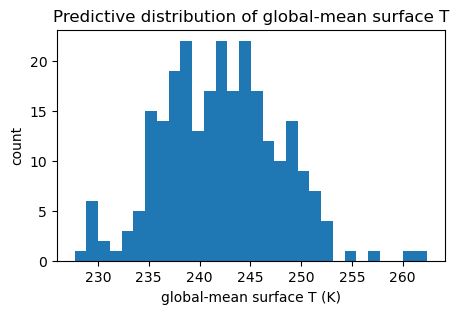

In [2]:
samples = emu.sample(INPUTS, n_samples=256, seed=0)
lat = latitude_centers(samples["surface_temperature"].shape[1])
gm = np.array([global_mean(s, lat) for s in samples["surface_temperature"]])
print(f"global-mean surface T: {gm.mean():.2f} ± {gm.std(ddof=1):.2f} K")

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(gm, bins=30)
ax.set(xlabel="global-mean surface T (K)", ylabel="count", title="Climate distribution of global-mean surface T")
plt.show()

## (b) Skewed fields: summarise in model space

Nonlinearly-transformed fields (humidity, cloud fraction) are skewed in physical space, so a physical mean ± std is misleading — the std runs past zero. Reduce in **model** space (where the climate distribution is Gaussian), then inverse-transform the summary with `to_physical`. Quantiles map exactly under the transform, giving a physical median and an asymmetric, always-positive interval.

In [3]:
field = "specific_humidity_5"
draws = emu.sample(INPUTS, n_samples=256, seed=0, space="model")[field]
mu, sd = draws.mean(0), draws.std(0, ddof=1)
band = emu.to_physical(field, np.stack([mu - sd, mu, mu + sd]), INPUTS)
lo, med, hi = (float(b.mean()) for b in band)
print(f"via model space  16/50/84: {lo:.2e} / {med:.2e} / {hi:.2e}  (asymmetric, all > 0)")

naive = emu.sample(INPUTS, n_samples=256, seed=0)[field]
print(f"naive physical   mean±std: {naive.mean():.2e} ± {naive.std():.2e}  (std implies negatives)")

via model space  16/50/84: 8.89e-05 / 1.85e-04 / 3.86e-04  (asymmetric, all > 0)


naive physical   mean±std: 2.41e-04 ± 4.69e-04  (std implies negatives)


## (c) Uncertainty grows outside the core domain

The emulator's predictive uncertainty widens as inputs move away from the training data. Sweeping radius from sub-Earth out into the extended domain (the core domain spans 0.7–1.75 R⊕), the model-space predictive standard deviation of surface temperature climbs on either side — an empirical version of the scope-of-validity warning in `SCOPE.md`. The same thing happens for instellation: stepping F_star outside its core domain (500–1500 W/m²) inflates the predictive uncertainty in the same way.

> **NOTE.** These curves are the *mean pointwise* predictive std — the area-weighted average over the map of each grid cell's marginal std (from the diagonal `return_variance`). This is **not** the uncertainty of a summary scalar such as the global-mean surface temperature: that depends on the spatial covariance *between* cells, which the diagonal variance cannot capture, and so must be estimated from coherent samples. See `using_clero_samples.ipynb` for the sample-based, covariance-correct version.

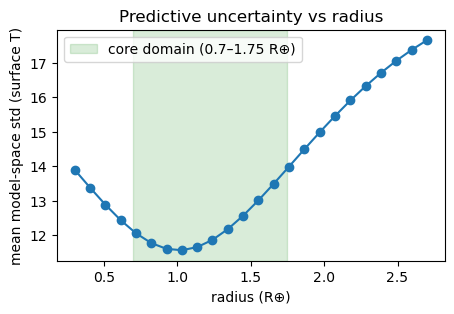

In [4]:
radii = np.linspace(0.3, 2.7, 24)  # spans the extended domain (0.26–2.76 R⊕)
n = radii.size
base = dict(T_star=3000.0, F_star=1000.0, gravity=9.8, P_rot=10.0, P0=1.0, CO2=4.0e-4, CH4=0.0)
batch = {key: np.full(n, value) for key, value in base.items()}
batch["radius"] = radii
batch["GCM"] = ["um"] * n

_, var = emu.predict(batch, space="model", return_variance=True)
lat = latitude_centers(var["surface_temperature"].shape[1])
w = latitude_weights(lat)
mean_std = (np.sqrt(var["surface_temperature"]).mean(axis=2) * w[None]).sum(axis=1)

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(radii, mean_std, marker="o")
ax.axvspan(0.7, 1.75, alpha=0.15, color="green", label="core domain (0.7–1.75 R⊕)")
ax.set(xlabel="radius (R⊕)", ylabel="mean model-space std (surface T)", title="Predictive uncertainty vs radius")
ax.legend()
plt.show()

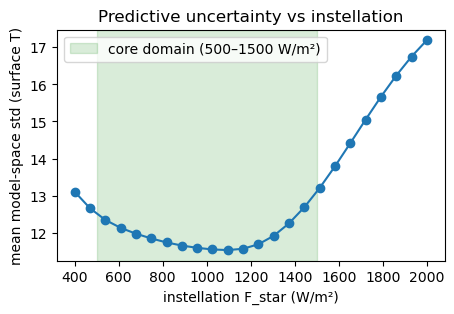

In [5]:
fluxes = np.linspace(400.0, 2000.0, 24)  # stays inside the extended domain (400–3100 W/m²)
n = fluxes.size
base = dict(T_star=3000.0, radius=1.0, gravity=9.8, P_rot=10.0, P0=1.0, CO2=4.0e-4, CH4=0.0)
batch = {key: np.full(n, value) for key, value in base.items()}
batch["F_star"] = fluxes
batch["GCM"] = ["um"] * n

_, var = emu.predict(batch, space="model", return_variance=True)
lat = latitude_centers(var["surface_temperature"].shape[1])
w = latitude_weights(lat)
mean_std = (np.sqrt(var["surface_temperature"]).mean(axis=2) * w[None]).sum(axis=1)

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(fluxes, mean_std, marker="o")
ax.axvspan(500.0, 1500.0, alpha=0.15, color="green", label="core domain (500–1500 W/m²)")
ax.set(xlabel="instellation F_star (W/m²)", ylabel="mean model-space std (surface T)", title="Predictive uncertainty vs instellation")
ax.legend()
plt.show()